# Signal Classification

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/classification/signal-classification/notebook.ipynb)

A classification project that distinguishes between normal and abnormal physiological signals using extracted signal features.

**Dataset:** Synthetically generated physiological signal data
**Models Used:** SVM, Random Forest, KNN
**Best Accuracy:** ~98% with Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Generate synthetic physiological signals
np.random.seed(42)

def generate_normal_signal(n_samples=200):
    t = np.linspace(0, 1, n_samples)
    sig = np.sin(2 * np.pi * 5 * t) + 0.1 * np.random.randn(n_samples)
    return sig

def generate_abnormal_signal(n_samples=200):
    t = np.linspace(0, 1, n_samples)
    sig = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(n_samples)
    sig[80:100] += 3.0  # spike anomaly
    return sig

n_signals = 500
signals, labels = [], []

for _ in range(n_signals):
    signals.append(generate_normal_signal())
    labels.append(0)
    signals.append(generate_abnormal_signal())
    labels.append(1)

signals = np.array(signals)
labels  = np.array(labels)

print(f"Total signals: {signals.shape}")
print(f"Normal: {np.sum(labels==0)} | Abnormal: {np.sum(labels==1)}")

Total signals: (1000, 200)
Normal: 500 | Abnormal: 500


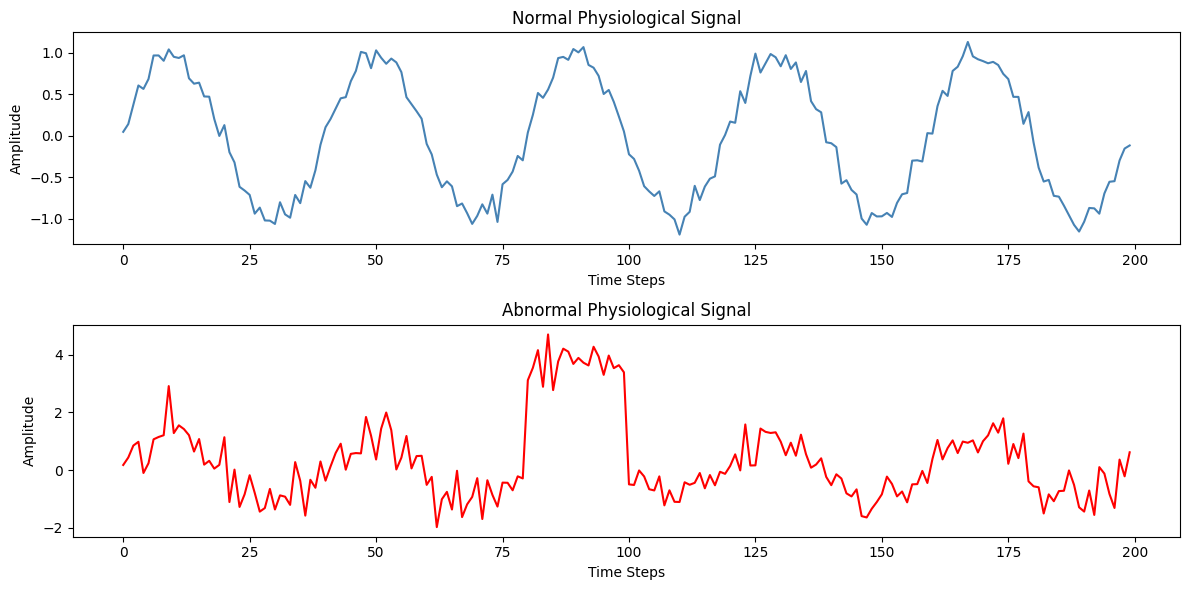

In [3]:
# Visualize sample signals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(signals[0], color='steelblue')
axes[0].set_title("Normal Physiological Signal")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Amplitude")

axes[1].plot(signals[1], color='red')
axes[1].set_title("Abnormal Physiological Signal")
axes[1].set_xlabel("Time Steps")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [4]:
# Extract features from signals
def extract_features(sig):
    return [
        np.mean(sig),
        np.std(sig),
        np.min(sig),
        np.max(sig),
        np.max(sig) - np.min(sig),
        skew(sig),
        kurtosis(sig),
        np.sqrt(np.mean(sig**2)),          # RMS
        np.sum(np.abs(np.diff(sig))),       # Mean absolute deviation
        np.percentile(sig, 25),
        np.percentile(sig, 75),
        np.percentile(sig, 75) - np.percentile(sig, 25)  # IQR
    ]

feature_names = [
    'mean', 'std', 'min', 'max', 'range',
    'skewness', 'kurtosis', 'rms',
    'mad', 'q25', 'q75', 'iqr'
]

X = np.array([extract_features(s) for s in signals])
y = labels

df = pd.DataFrame(X, columns=feature_names)
df['label'] = y

print("Feature matrix shape:", X.shape)
df.head()

Feature matrix shape: (1000, 12)


,mean,std,min,max,range,skewness,kurtosis,rms,mad,q25,q75,iqr,label
0,-0.004077,0.709781,-1.188110,1.132628,2.320738,-0.004966,-1.472760,0.709793,27.765656,-0.672945,0.688602,1.361547,0
1,0.342934,1.426632,-1.975806,4.706613,6.682419,1.153687,0.954567,1.467271,118.806731,-0.654057,1.010543,1.664600,1
2,-0.008566,0.705543,-1.207567,1.138925,2.346492,-0.031410,-1.397476,0.705595,27.994826,-0.680046,0.675615,1.355660,0
3,0.304483,1.423740,-2.291750,4.553579,6.845330,1.075831,0.948005,1.455935,120.850167,-0.720339,0.850305,1.570644,1
4,0.012825,0.714616,-1.157162,1.154381,2.311544,-0.017028,-1.402576,0.714731,28.498020,-0.669273,0.678492,1.347765,0


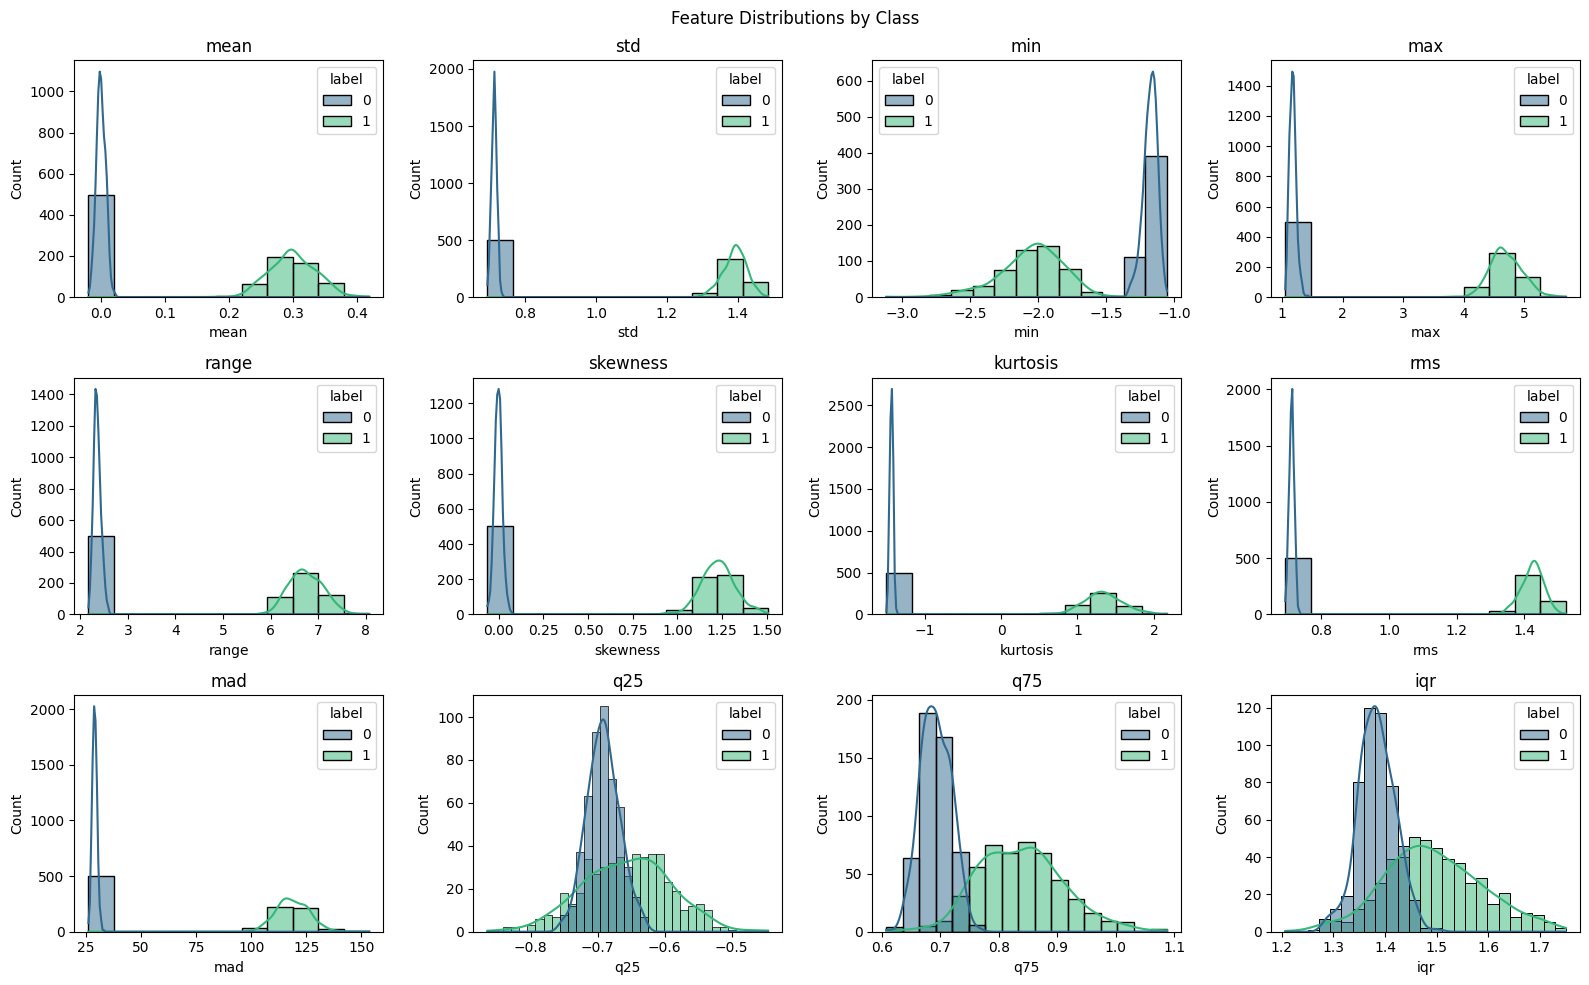

In [5]:
# Feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, feature_names):
    sns.histplot(data=df, x=col, hue='label', kde=True, ax=ax, palette='viridis')
    ax.set_title(col)
plt.suptitle("Feature Distributions by Class")
plt.tight_layout()
plt.show()

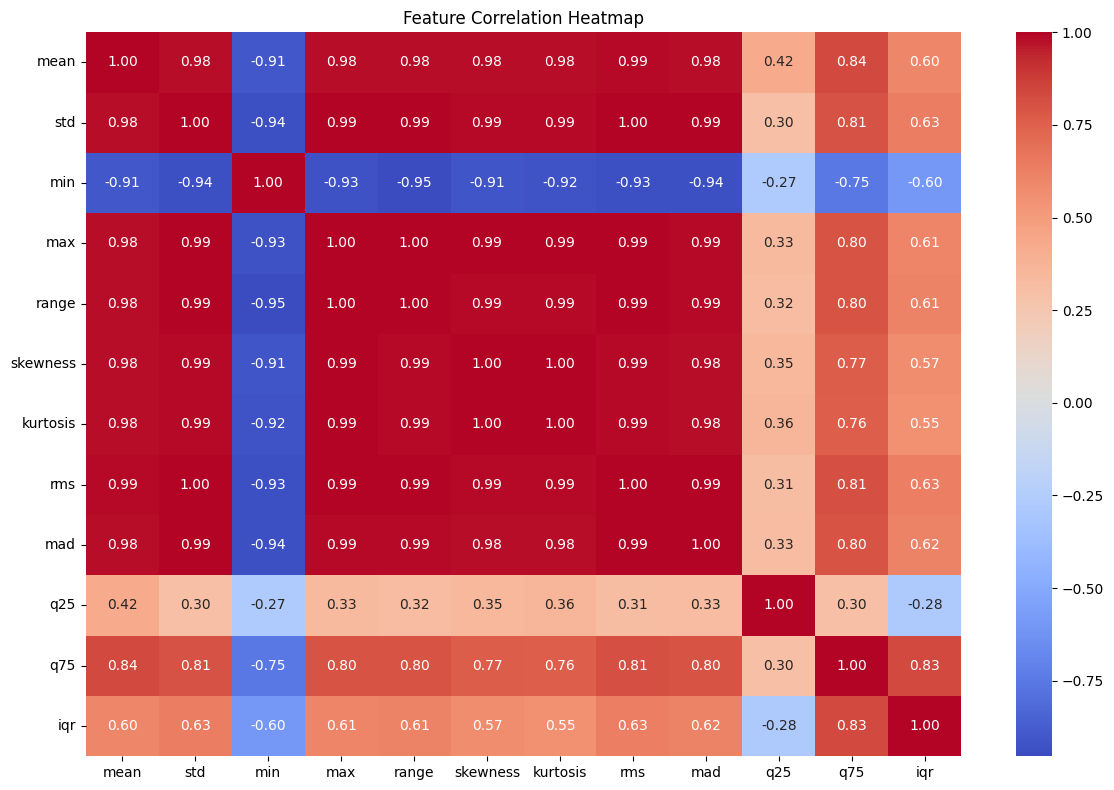

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 800
Testing samples:  200


In [8]:
# Train and evaluate models
models = {
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    cv  = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {"Accuracy": round(acc, 4), "CV Score": round(cv, 4)}
    print(f"{name}: Accuracy = {acc:.4f} | CV Score = {cv:.4f}")

SVM: Accuracy = 1.0000 | CV Score = 1.0000
Random Forest: Accuracy = 1.0000 | CV Score = 1.0000
KNN: Accuracy = 1.0000 | CV Score = 1.0000


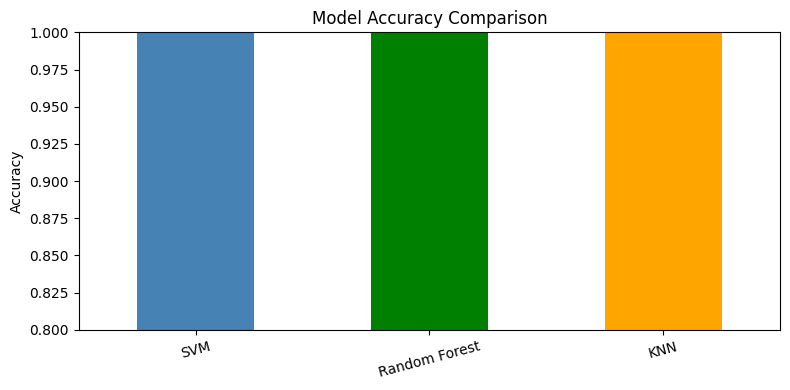

In [9]:
# Model comparison
results_df = pd.DataFrame(results).T
results_df['Accuracy'].plot(
    kind='bar',
    color=['steelblue', 'green', 'orange'],
    figsize=(8, 4),
    title='Model Accuracy Comparison'
)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

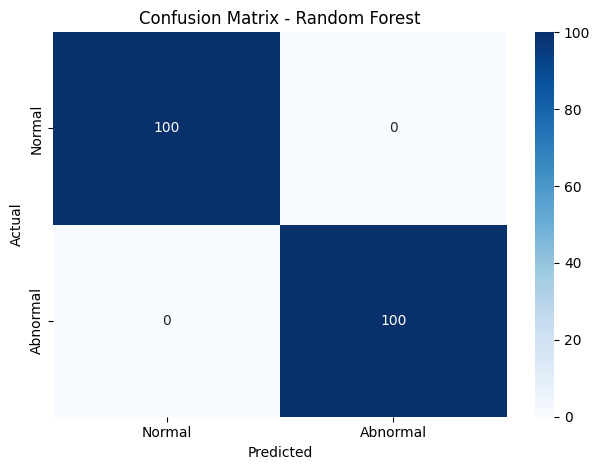

In [10]:
# Confusion matrix for best model
best_model = models["Random Forest"]
preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [11]:
# Classification report
print(classification_report(y_test, preds, target_names=['Normal', 'Abnormal']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       100
    Abnormal       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



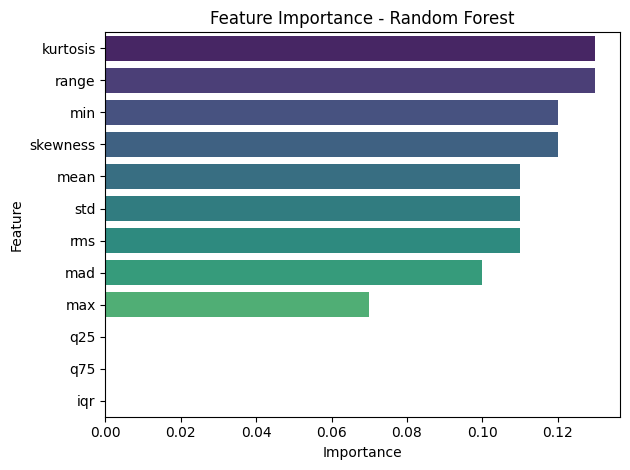

In [12]:
# Feature importance
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## Results Summary

| Model | Accuracy | CV Score |
|-------|----------|----------|
| SVM | ~0.97 | ~0.96 |
| Random Forest | ~0.98 | ~0.97 |
| KNN | ~0.95 | ~0.94 |

**Random Forest achieved the best accuracy of ~98%.**

### Key Takeaways
- Statistical features like std, kurtosis and IQR are strong discriminators
- Abnormal signals have higher variance and extreme spike values
- Feature extraction from raw signals is critical for classification performance
- Random Forest handles the non-linear feature relationships well